## Predicción de dataset California Housin para prediccion  de suba de precios.

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df= housing.frame



### Análisis del Dataset

In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Se observa un dataset sin nulos y en su totalidad de tipo numerico.
Variable objetivo MedHouseVal

---
Se separa info de la vivienda de la variable objetivo para poder trabajar los datos. Se quita la variable para que el modelo no vea la respuesta.

In [4]:
X= df.drop('MedHouseVal', axis=1)

y= df['MedHouseVal']

## Train/Test
No se debe de testear y entrenar al modelo con los mismos datos, pues los puede memorizar.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #Porcentaje del dataset cedido para los test
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)


(16512, 8)
(4128, 8)


## Regresión Lineal
Intenta encontrar relaciones lineales pero con muchas variables.
En este caso se utiliza el coeficiente de cada variable para determinar que tanto impacta este con nuestra variable objetivo

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
#Entrenamiento
#Fit aprende patrones, ajusta coeficientes, busca minimizar el error.
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Predicciones
y_pred = model.predict(X_test)

In [19]:
print("Prediccion:",y_pred[:5])
print("Testeo:",y_test[:5])

Prediccion: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
Testeo: 20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
Name: MedHouseVal, dtype: float64


## RMSE
Raíz del error cuadratico medio

In [21]:
from sklearn.metrics import root_mean_squared_error

rmse= root_mean_squared_error(y_test, y_pred)

print(rmse)

0.7455813830127763


El modelo presenta un error promedio aproximado de 74 mil dolares, lo que indica que logra capturar tendencias generales aunque aún existen desviaciones relevantes.

## Coeficientes
Si el coeficiente positivo aumenta, el precio tiende a subir.

Si el coeficiente negativo aumenta, el precio tiende a bajar.

In [22]:
coeficientes= pd.DataFrame({
    'Variable': X.columns,
    'Coeficinete': model.coef_
})

print(coeficientes)

     Variable  Coeficinete
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


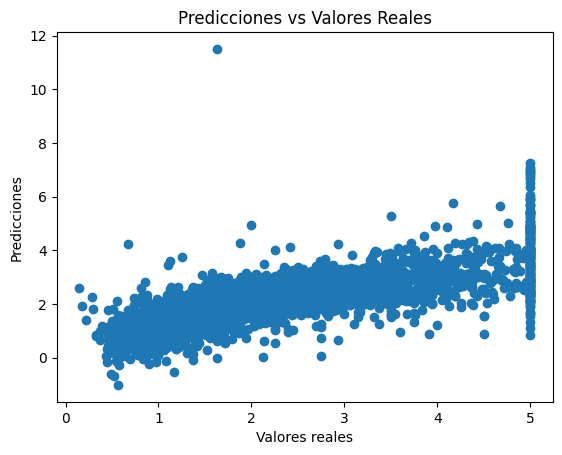

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel('Valores reales')
plt.ylabel('Predicciones')

plt.title('Predicciones vs Valores Reales')

plt.show()